In [1]:
library(nnet)
library(class)
library(caret)
library(pROC)
library(ggplot2)

# 1. Загрузка данных
df <- read.csv("features_3_sec.csv", stringsAsFactors = FALSE)

# Предобработка данных
X <- df[, !(names(df) %in% c("filename", "label"))]
y <- as.factor(df$label)

# Разделение на train/test (70/30)
set.seed(42)
trainIndex <- createDataPartition(y, p = 0.7, list = FALSE)
X_train <- X[trainIndex, ]
X_test <- X[-trainIndex, ]
y_train <- y[trainIndex]
y_test <- y[-trainIndex]

# Удаление признаков с нулевой дисперсией и корреляцией
preProc <- preProcess(X_train, method = c("zv", "corr"))
X_train_processed <- predict(preProc, X_train)
X_test_processed <- predict(preProc, X_test)

# Масштабирование
X_train_scaled <- scale(X_train_processed)
X_test_scaled <- scale(X_test_processed)



Загрузка требуемого пакета: ggplot2

Загрузка требуемого пакета: lattice

Type 'citation("pROC")' for a citation.


Присоединяю пакет: 'pROC'


Следующие объекты скрыты от 'package:stats':

    cov, smooth, var




In [2]:
# 2. Логистическая регрессия (многоклассовая)
model_log <- multinom(y_train ~ ., data = as.data.frame(X_train_scaled))
summary(model_log)

# Предсказания
y_pred_logreg <- predict(model_log, newdata = as.data.frame(X_test_scaled))
y_pred_prob_logreg <- predict(model_log, newdata = as.data.frame(X_test_scaled), type = "probs")

# weights:  560 (495 variable)
initial  value 16106.582725 
iter  10 value 7240.055730
iter  20 value 6651.004677
iter  30 value 6386.549546
iter  40 value 6087.910563
iter  50 value 5887.922505
iter  60 value 5797.582947
iter  70 value 5733.686379
iter  80 value 5667.533100
iter  90 value 5583.446858
iter 100 value 5542.151689
final  value 5542.151689 
stopped after 100 iterations


Call:
multinom(formula = y_train ~ ., data = as.data.frame(X_train_scaled))

Coefficients:
          (Intercept) chroma_stft_mean chroma_stft_var   rms_mean     rms_var
classical  -2.3995401       0.15179469      -1.4800756 -4.4935300 -0.11218092
country     1.4507728      -0.46762572      -0.9985473 -6.2165469 -2.02178555
disco       1.4665555       0.58187777      -0.5661118 -3.5518504 -0.77286985
hiphop      1.3587601       2.05367756      -0.2847023  0.2605101 -0.24617786
jazz       -0.3422503      -0.47168886      -0.5794993 -0.7578223 -0.09354141
metal      -2.8682246       1.63655612      -0.2977774 -3.5037633 -2.40607342
pop        -0.8583275      -0.03997558      -1.1786543 -2.1473491 -0.71273814
reggae      1.7278324       0.68049034      -0.6270870 -1.4662094 -0.83838367
rock        1.3009566       0.27196899      -0.4243809 -2.0355296 -1.86443000
          spectral_centroid_var spectral_bandwidth_var rolloff_mean rolloff_var
classical             0.8451191            -0.702

In [3]:
# Подбор оптимального k (пример для k=5)
k <- 5
knn_pred <- knn(
  train = X_train_scaled,
  test = X_test_scaled,
  cl = y_train,
  k = k,
  prob = TRUE # Включаем вероятности
)

# Получение вероятностей для KNN
knn_prob <- attr(knn_pred, "prob") # Извлекаем вероятности из атрибутов

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


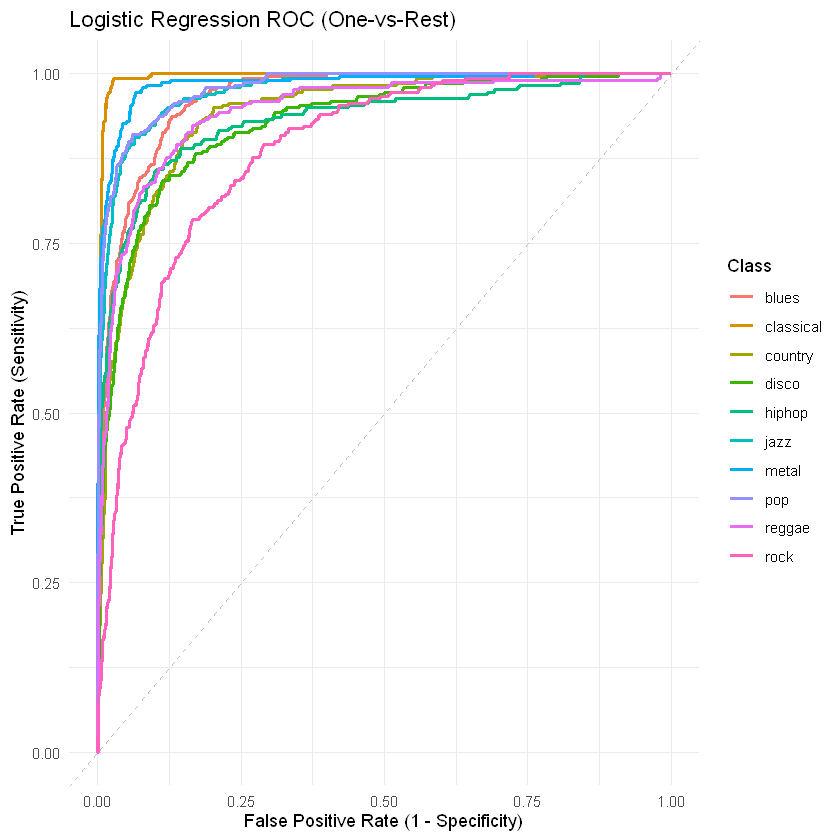

In [4]:
# Подготовка данных для ROC-кривых
roc_data <- data.frame()
for (i in levels(y_test)) {
  y_test_bin <- ifelse(y_test == i, 1, 0)
  roc_obj <- roc(y_test_bin, y_pred_prob_logreg[, i], quiet = TRUE)
  
  # Добавляем данные для текущего класса
  roc_data <- rbind(roc_data, data.frame(
    Class = i,
    FPR = 1 - roc_obj$specificities,
    TPR = roc_obj$sensitivities
  ))
}

# Визуализация ROC-кривых
ggplot(roc_data, aes(x = FPR, y = TPR, color = Class)) +
  geom_line(size = 1) + # Линии ROC-кривых
  geom_abline(linetype = "dashed", color = "gray") + # Случайная модель
  labs(
    title = "Logistic Regression ROC (One-vs-Rest)",
    x = "False Positive Rate (1 - Specificity)",
    y = "True Positive Rate (Sensitivity)"
  ) +
  theme_minimal()

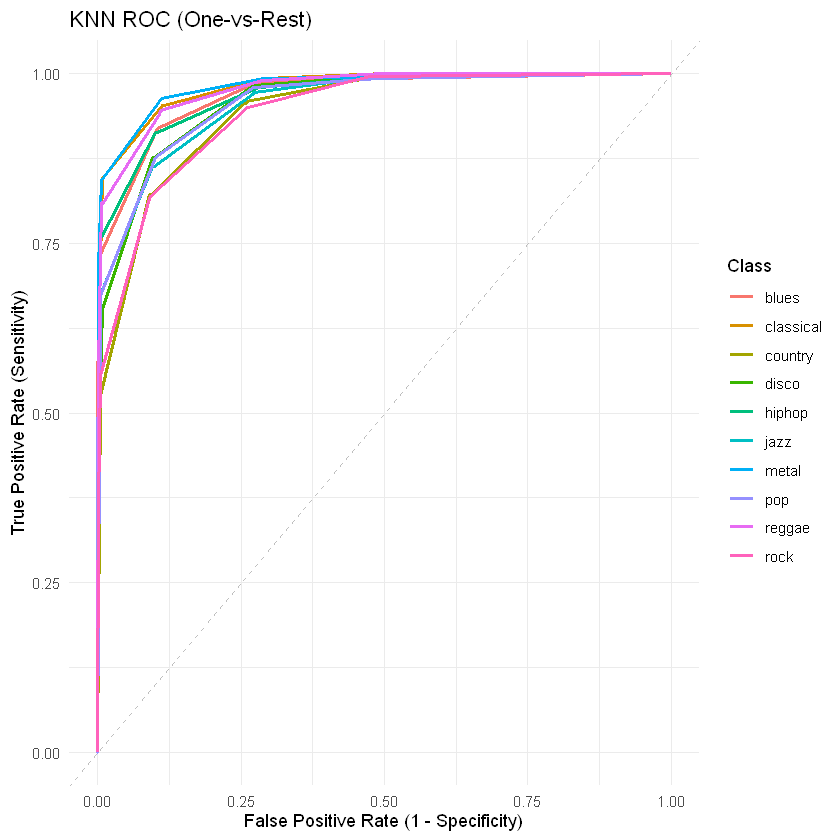

In [5]:
# Подготовка данных для ROC-кривых
roc_data_knn <- data.frame()
for (i in levels(y_test)) {
  y_test_bin <- ifelse(y_test == i, 1, 0)
  knn_prob_bin <- ifelse(knn_pred == i, knn_prob, 1 - knn_prob)
  roc_obj <- roc(y_test_bin, knn_prob_bin, quiet = TRUE)
  
  # Добавляем данные для текущего класса
  roc_data_knn <- rbind(roc_data_knn, data.frame(
    Class = i,
    FPR = 1 - roc_obj$specificities,
    TPR = roc_obj$sensitivities
  ))
}

# Визуализация ROC-кривых
ggplot(roc_data_knn, aes(x = FPR, y = TPR, color = Class)) +
  geom_line(size = 1) + # Линии ROC-кривых
  geom_abline(linetype = "dashed", color = "gray") + # Случайная модель
  labs(
    title = "KNN ROC (One-vs-Rest)",
    x = "False Positive Rate (1 - Specificity)",
    y = "True Positive Rate (Sensitivity)"
  ) +
  theme_minimal()

In [6]:
# Сравнение моделей
conf_matrix_logreg <- confusionMatrix(factor(y_pred_logreg), factor(y_test))
conf_matrix_knn <- confusionMatrix(factor(knn_pred), factor(y_test))

results <- data.frame(
  Model = c("LogReg", "KNN"),
  Accuracy = c(conf_matrix_logreg$overall["Accuracy"], conf_matrix_knn$overall["Accuracy"]),
  Macro_Precision = c(mean(conf_matrix_logreg$byClass[,"Precision"]), mean(conf_matrix_knn$byClass[,"Precision"])),
  Macro_Recall = c(mean(conf_matrix_logreg$byClass[,"Recall"]), mean(conf_matrix_knn$byClass[,"Recall"])),
  Macro_F1 = c(mean(conf_matrix_logreg$byClass[,"F1"]), mean(conf_matrix_knn$byClass[,"F1"]))
)

print(results)

   Model  Accuracy Macro_Precision Macro_Recall  Macro_F1
1 LogReg 0.7212020       0.7177504    0.7211327 0.7185721
2    KNN 0.8627713       0.8639205    0.8627414 0.8626015
